In [4]:
import logging
import sys

# Clear any existing handlers
logging.getLogger().handlers.clear()

# Configure the root logger
logging.basicConfig(
    format="%(asctime)s : %(levelname)s : %(message)s",
    level=logging.INFO,
    stream=sys.stdout,  # Explicitly use stdout
)

# Also configure gensim's logger specifically
logging.getLogger("gensim").setLevel(logging.DEBUG)

# If you want to see logs from your lda_model_gensim module
logging.getLogger("lda_model_gensim").setLevel(logging.DEBUG)

In [5]:
from pathlib import Path

import gensim

import utils

cofig_path = "config.yaml"

# Load configuration
config = utils.load_config(cofig_path)

# load the train and val data from the preprocessed directory
preprocessed_dir = Path("outputs/run_20251011_153357/preprocessed")

train_dictionary = gensim.corpora.Dictionary.load(
    str(preprocessed_dir / "train_dictionary.id2word")
)
train_bow_corpus = gensim.corpora.MmCorpus(
    str(preprocessed_dir / "train_bow_corpus.mm")
)
val_bow_corpus = gensim.corpora.MmCorpus(str(preprocessed_dir / "val_bow_corpus.mm"))
test_bow_corpus = gensim.corpora.MmCorpus(str(preprocessed_dir / "test_bow_corpus.mm"))
train_val_bow_corpus = gensim.corpora.MmCorpus(
    str(preprocessed_dir / "train_val_bow_corpus.mm")
)

logging.info(f"Loaded train corpus: {len(train_bow_corpus)}")
logging.info(f"Loaded val corpus: {len(val_bow_corpus)}")
logging.info(f"Loaded test corpus: {len(test_bow_corpus)}")
logging.info(f"Loaded train_val corpus: {len(train_val_bow_corpus)}")
logging.info(f"Loaded train_dictionary with tokens: {len(train_dictionary)}")

2025-10-12 14:50:40,602 : INFO : loading Dictionary object from outputs/run_20251011_153357/preprocessed/train_dictionary.id2word
2025-10-12 14:50:40,609 : INFO : Dictionary lifecycle event {'fname': 'outputs/run_20251011_153357/preprocessed/train_dictionary.id2word', 'datetime': '2025-10-12T14:50:40.609673', 'gensim': '4.3.2', 'python': '3.12.11 (main, Aug 14 2025, 16:05:17) [Clang 20.1.4 ]', 'platform': 'macOS-26.0.1-arm64-arm-64bit', 'event': 'loaded'}
2025-10-12 14:50:40,610 : INFO : loaded corpus index from outputs/run_20251011_153357/preprocessed/train_bow_corpus.mm.index
2025-10-12 14:50:40,610 : INFO : initializing cython corpus reader from outputs/run_20251011_153357/preprocessed/train_bow_corpus.mm
2025-10-12 14:50:40,611 : INFO : accepted corpus with 2590 documents, 29420 features, 3487139 non-zero entries
2025-10-12 14:50:40,612 : INFO : loaded corpus index from outputs/run_20251011_153357/preprocessed/val_bow_corpus.mm.index
2025-10-12 14:50:40,612 : INFO : initializing cy

In [110]:
import numpy as np

topics = [
    1,
    2,
    5,
    10,
    # 5,
    # 10,
    # 15,
    # 20,
    # 25,
    # 30,
    # 35,
    # 25, 30, 35, 40, 45, 50
]

perplexity_scores = {}
lda_models = {}

for num_topics in topics:
    logging.info(f"Training 3 models for {num_topics} topics (random initializations)")
    best_train_perplexity = None
    best_lda_model = None
    best_val_perplexity = None

    for init_id in range(3):
        logging.info(f"  Random init {init_id + 1}/3")
        lda_model_candidate = gensim.models.LdaModel(
            corpus=train_bow_corpus,
            id2word=train_dictionary,
            num_topics=num_topics,
            chunksize=3000,
            passes=10,
            iterations=3000,
            update_every=1,
            eval_every=None,
            alpha="auto",
            eta="auto",
            random_state=np.random.randint(0, 1_000_000),
        )
        train_perplexity_candidate = np.exp2(
            -lda_model_candidate.log_perplexity(train_bow_corpus)
        )
        val_perplexity_candidate = np.exp2(
            -lda_model_candidate.log_perplexity(val_bow_corpus)
        )
        logging.info(f"    Train perplexity: {train_perplexity_candidate}")

        # Check if this is the best model so far
        if (best_train_perplexity is None) or (
            train_perplexity_candidate < best_train_perplexity
        ):
            # Update best model
            best_lda_model = lda_model_candidate
            best_train_perplexity = train_perplexity_candidate
            best_val_perplexity = val_perplexity_candidate

    perplexity_scores[num_topics] = {
        "train_perplexity": best_train_perplexity,
        "val_perplexity": best_val_perplexity,
    }
    lda_model = best_lda_model  # Store last "best" model for further analysis/plots outside loop if needed

    lda_models[num_topics] = lda_model

2025-10-12 23:26:40,004 : INFO : Training 3 models for 10 topics (random initializations)
2025-10-12 23:26:40,005 : INFO :   Random init 1/3
2025-10-12 23:26:40,006 : INFO : using autotuned alpha, starting with [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
2025-10-12 23:26:40,009 : INFO : using serial LDA version on this node
2025-10-12 23:26:40,028 : INFO : running online (multi-pass) LDA training, 10 topics, 10 passes over the supplied corpus of 2590 documents, updating model once every 2590 documents, evaluating perplexity every 0 documents, iterating 3000x with a convergence threshold of 0.001000
2025-10-12 23:26:40,680 : INFO : PROGRESS: pass 0, at document #2590/2590
2025-10-12 23:26:40,680 : DEBUG : performing inference on a chunk of 2590 documents
2025-10-12 23:29:21,710 : DEBUG : 2156/2590 documents converged within 3000 iterations
2025-10-12 23:29:21,719 : INFO : optimized alpha [0.07108366, 0.06863597, 0.04545589, 0.080423206, 0.08432552, 0.043214846, 0.07280904, 0.0532

In [102]:
# lda_model.log_perplexity(train_bow_corpus[:100])
print(np.exp2(-lda_model.log_perplexity(val_bow_corpus[:100])))
print(np.exp2(-lda_model.log_perplexity(val_bow_corpus[100:200])))
print(np.exp2(-lda_model.log_perplexity(val_bow_corpus[-200:])))
print(np.exp2(-lda_model.log_perplexity(val_bow_corpus[:200])))
print(np.exp2(-lda_model.log_perplexity(val_bow_corpus)))

2025-10-12 22:18:32,526 : DEBUG : bound: at document #0
2025-10-12 22:18:34,901 : INFO : -9.548 per-word bound, 748.7 perplexity estimate based on a held-out corpus of 100 documents with 988416 words
748.733317550239
2025-10-12 22:18:34,963 : DEBUG : bound: at document #0
2025-10-12 22:18:35,978 : INFO : -11.548 per-word bound, 2995.1 perplexity estimate based on a held-out corpus of 100 documents with 391125 words
2995.119415241334
2025-10-12 22:18:36,060 : DEBUG : bound: at document #0
2025-10-12 22:18:37,807 : INFO : -10.124 per-word bound, 1115.7 perplexity estimate based on a held-out corpus of 200 documents with 690866 words
1115.6715457769244
2025-10-12 22:18:37,926 : DEBUG : bound: at document #0
2025-10-12 22:18:41,310 : INFO : -9.199 per-word bound, 587.8 perplexity estimate based on a held-out corpus of 200 documents with 1379541 words
587.7993519785676
2025-10-12 22:18:41,444 : DEBUG : bound: at document #0
2025-10-12 22:18:44,538 : INFO : -9.169 per-word bound, 575.8 perpl

2025-10-12 22:22:59,408 : DEBUG : bound: at document #0
2025-10-12 22:22:59,425 : INFO : -3885.019 per-word bound, inf perplexity estimate based on a held-out corpus of 1 documents with 326 words
2025-10-12 22:22:59,437 : DEBUG : bound: at document #0
2025-10-12 22:22:59,450 : INFO : -3885.019 per-word bound, inf perplexity estimate based on a held-out corpus of 1 documents with 326 words
2025-10-12 22:22:59,461 : DEBUG : bound: at document #0
2025-10-12 22:22:59,473 : INFO : -3885.019 per-word bound, inf perplexity estimate based on a held-out corpus of 1 documents with 326 words
2025-10-12 22:22:59,484 : DEBUG : bound: at document #0
2025-10-12 22:22:59,496 : INFO : -4125.372 per-word bound, inf perplexity estimate based on a held-out corpus of 1 documents with 307 words
2025-10-12 22:22:59,508 : DEBUG : bound: at document #0
2025-10-12 22:22:59,543 : INFO : -133.293 per-word bound, 13344318070659159507281636594227116769280.0 perplexity estimate based on a held-out corpus of 1 docume

/Users/anugrah/Desktop/financial_topic_modeling/.venv/lib/python3.12/site-packages/gensim/models/ldamodel.py:850: RuntimeWarning: overflow encountered in exp2
  perwordbound, np.exp2(-perwordbound), len(chunk), corpus_words


2025-10-12 22:22:59,666 : INFO : -133.293 per-word bound, 13344316212670006139068288556422999834624.0 perplexity estimate based on a held-out corpus of 1 documents with 10103 words
2025-10-12 22:22:59,684 : DEBUG : bound: at document #0
2025-10-12 22:22:59,713 : INFO : -8162.354 per-word bound, inf perplexity estimate based on a held-out corpus of 1 documents with 155 words
2025-10-12 22:22:59,738 : DEBUG : bound: at document #0
2025-10-12 22:22:59,759 : INFO : -8162.354 per-word bound, inf perplexity estimate based on a held-out corpus of 1 documents with 155 words
2025-10-12 22:22:59,790 : DEBUG : bound: at document #0
2025-10-12 22:22:59,829 : INFO : -69.190 per-word bound, 673230354539415994368.0 perplexity estimate based on a held-out corpus of 1 documents with 20539 words
2025-10-12 22:22:59,843 : DEBUG : bound: at document #0
2025-10-12 22:22:59,875 : INFO : -69.190 per-word bound, 673230354883389947904.0 perplexity estimate based on a held-out corpus of 1 documents with 20539 w

/var/folders/82/tm1msdp96334j_2xqbgc_knm0000gn/T/ipykernel_14483/1492624412.py:26: RuntimeWarning: overflow encountered in exp2
  print(pd.Series(np.exp2(-ppl_train)).describe())
/Users/anugrah/Desktop/financial_topic_modeling/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/var/folders/82/tm1msdp96334j_2xqbgc_knm0000gn/T/ipykernel_14483/1492624412.py:27: RuntimeWarning: overflow encountered in exp2
  print(pd.Series(np.exp2(-ppl_val)).describe())
/Users/anugrah/Desktop/financial_topic_modeling/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  3.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,
         0.,  0.,  1.,  0.,  5.,  8.,  8., 33., 35.]),
 array([-7668.51484934, -7592.2090164 , -7515.90318346, -7439.59735051,
        -7363.29151757, -7286.98568463, -7210.67985168, -7134.37401874,
        -7058.0681858 , -6981.76235285, -6905.45651991, -6829.15068697,
        -6752.84485402, -6676.53902108, -6600.23318814, -6523.92735519,
        -6447.62152225, -6371.31568931, -6295.00985636, -6218.70402342,
        -6142.39819048, -6066.09235753, -5989.78652459, -5913.48069165,
  

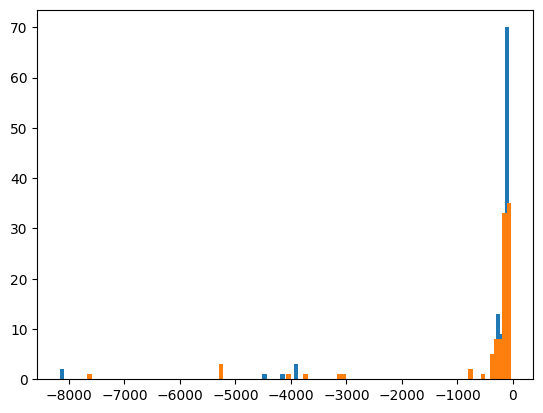

In [103]:
# for i in range(10):
#     print(lda_model.bound([train_bow_corpus[i]]))
#     print(lda_model.bound([val_bow_corpus[i]]))
# # lda_model.state.get_lambda().sum(-1)


# plt.plot([np.array(_bow_doc).sum(0)[1] for _bow_doc in train_bow_corpus])
# plt.hist(
#     [lda_model.bound([_bow_doc]) for _bow_doc in val_bow_corpus], density=True, bins=100
# )
# plt.hist(
#     [lda_model.bound([_bow_doc]) for _bow_doc in train_bow_corpus],
#     density=True,
#     bins=100,
# )

import pandas as pd

ppl_train = np.array(
    [lda_model.log_perplexity([_bow_doc]) for _bow_doc in train_bow_corpus[:100]]
)
ppl_val = np.array(
    [lda_model.log_perplexity([_bow_doc]) for _bow_doc in val_bow_corpus[:100]]
)

print(pd.Series(np.exp2(-ppl_train)).describe())
print(pd.Series(np.exp2(-ppl_val)).describe())

plt.hist(
    ppl_train,
    # density=True,
    bins=100,
)
plt.hist(
    ppl_val,
    # density=True,
    bins=100,
)

# lda_model.log_perplexity(train_bow_corpus[:100])
# plt.plot([np.array(_bow_doc).sum(0)[1] for _bow_doc in test_bow_corpus])

# plt.plot([np.array(train_bow_corpus[i]).sum(0)[1] for i in range(1000)])
# plt.plot([np.array(val_bow_corpus[i]).sum(0)[1] for i in range(280)])


In [105]:
perplexity_scores

{1: {'train_perplexity': 378.74466651527587,
  'val_perplexity': 443.55911956513967},
 2: {'train_perplexity': 342.48585380405564,
  'val_perplexity': 408.0491370766074},
 5: {'train_perplexity': 312.3653620227374,
  'val_perplexity': 409.46914351825654}}

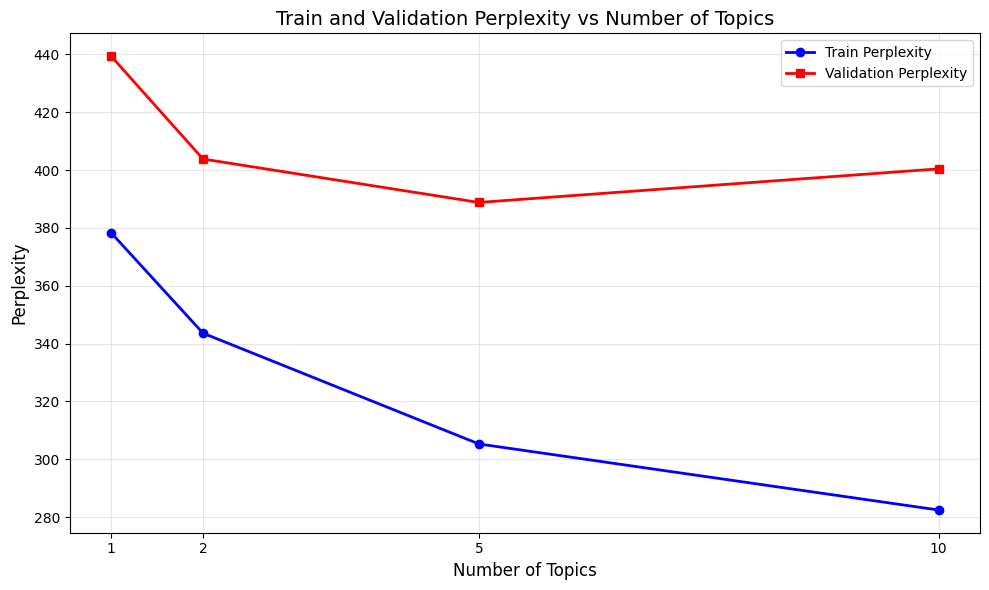

In [111]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from perplexity_scores
num_topics_list = sorted(perplexity_scores.keys())
train_perplexities = [perplexity_scores[n]["train_perplexity"] for n in num_topics_list]
val_perplexities = [perplexity_scores[n]["val_perplexity"] for n in num_topics_list]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(
    num_topics_list,
    train_perplexities,
    marker="o",
    linewidth=2,
    label="Train Perplexity",
    color="blue",
)
plt.plot(
    num_topics_list,
    val_perplexities,
    marker="s",
    linewidth=2,
    label="Validation Perplexity",
    color="red",
)

plt.xlabel("Number of Topics", fontsize=12)
plt.ylabel("Perplexity", fontsize=12)
plt.title("Train and Validation Perplexity vs Number of Topics", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.xticks(num_topics_list)
plt.show()


In [23]:
import json

model_save_dir = Path("outputs/run_20251011_153357/models_jupyter_symmetric")

model_save_dir.mkdir(parents=True, exist_ok=True)
lda_model.save(str(model_save_dir / "lda_model_20.model"))
plt.savefig(str(model_save_dir / "perplexity_plot.png"))
with open(str(model_save_dir / "metrics.json"), "w") as f:
    json.dump(perplexity_scores, f)


2025-10-12 17:50:15,509 : DEBUG : starting a new internal lifecycle event log for LdaState
2025-10-12 17:50:15,518 : INFO : LdaState lifecycle event {'fname_or_handle': 'outputs/run_20251011_153357/models_jupyter_symmetric/lda_model_20.model.state', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-10-12T17:50:15.509791', 'gensim': '4.3.2', 'python': '3.12.11 (main, Aug 14 2025, 16:05:17) [Clang 20.1.4 ]', 'platform': 'macOS-26.0.1-arm64-arm-64bit', 'event': 'saving'}
2025-10-12 17:50:15,526 : INFO : saved outputs/run_20251011_153357/models_jupyter_symmetric/lda_model_20.model.state
2025-10-12 17:50:15,536 : INFO : LdaModel lifecycle event {'fname_or_handle': 'outputs/run_20251011_153357/models_jupyter_symmetric/lda_model_20.model', 'separately': "['expElogbeta', 'sstats']", 'sep_limit': 10485760, 'ignore': ['id2word', 'dispatcher', 'state'], 'datetime': '2025-10-12T17:50:15.536256', 'gensim': '4.3.2', 'python': '3.12.11 (main, Aug 14 2025, 16:05:17)

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np

topics = [
    5,
    10,
    15,
    20,
    # 25, 30, 35, 40, 45, 50
]

perplexity_scores = {}

for num_topics in topics:
    logging.info(f"-----------Training model with {num_topics} topics-----------")
    lda_model = gensim.models.LdaModel(
        corpus=train_bow_corpus,
        id2word=train_dictionary,
        num_topics=num_topics,
        chunksize=3000,
        passes=10,
        iterations=3000,  # 3000
        update_every=1,
        eval_every=None,
        alpha="auto",
        eta="auto",
    )

    train_perplexity = np.exp2(
        -lda_model.log_perplexity(
            chunk=train_bow_corpus,
            total_docs=len(train_bow_corpus),
        )
    )
    val_perplexity = np.exp2(
        -lda_model.log_perplexity(
            chunk=val_bow_corpus,
            total_docs=len(val_bow_corpus),
        )
    )

    perplexity_scores[num_topics] = {
        "train_perplexity": train_perplexity,
        "val_perplexity": val_perplexity,
    }

2025-10-12 15:32:27,372 : INFO : -----------Training model with 5 topics-----------
2025-10-12 15:32:27,374 : INFO : using autotuned alpha, starting with [0.2, 0.2, 0.2, 0.2, 0.2]
2025-10-12 15:32:27,377 : INFO : using serial LDA version on this node
2025-10-12 15:32:27,388 : INFO : running online (multi-pass) LDA training, 5 topics, 10 passes over the supplied corpus of 2590 documents, updating model once every 2590 documents, evaluating perplexity every 2590 documents, iterating 3000x with a convergence threshold of 0.001000
2025-10-12 15:32:28,122 : DEBUG : bound: at document #0
2025-10-12 15:34:26,199 : INFO : -10.768 per-word bound, 1743.4 perplexity estimate based on a held-out corpus of 2590 documents with 13442688 words
2025-10-12 15:34:26,200 : INFO : PROGRESS: pass 0, at document #2590/2590
2025-10-12 15:34:26,200 : DEBUG : performing inference on a chunk of 2590 documents
2025-10-12 15:36:02,834 : DEBUG : 2271/2590 documents converged within 3000 iterations
2025-10-12 15:36:

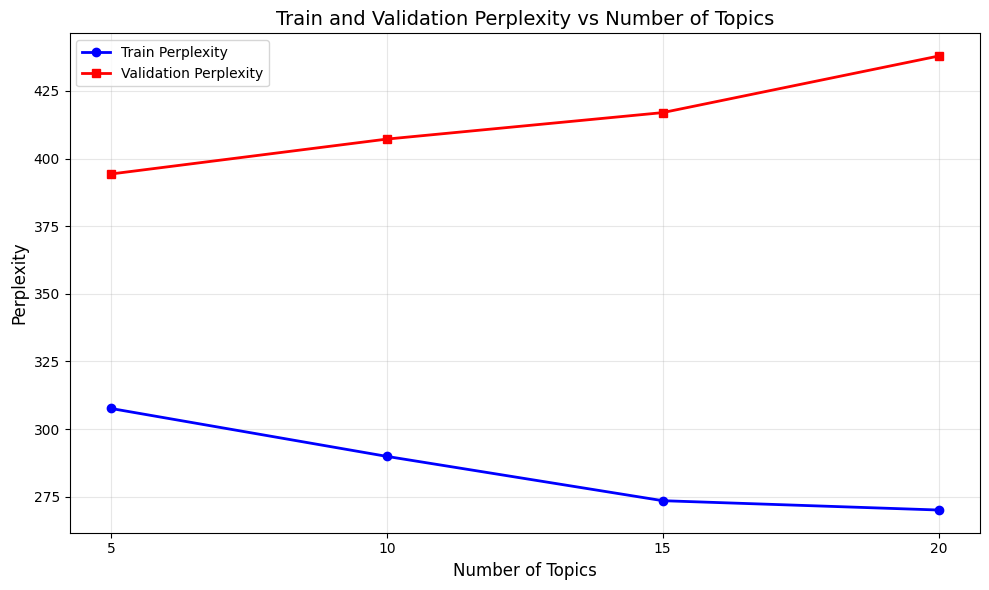

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from perplexity_scores
num_topics_list = sorted(perplexity_scores.keys())
train_perplexities = [perplexity_scores[n]["train_perplexity"] for n in num_topics_list]
val_perplexities = [perplexity_scores[n]["val_perplexity"] for n in num_topics_list]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(
    num_topics_list,
    train_perplexities,
    marker="o",
    linewidth=2,
    label="Train Perplexity",
    color="blue",
)
plt.plot(
    num_topics_list,
    val_perplexities,
    marker="s",
    linewidth=2,
    label="Validation Perplexity",
    color="red",
)

plt.xlabel("Number of Topics", fontsize=12)
plt.ylabel("Perplexity", fontsize=12)
plt.title("Train and Validation Perplexity vs Number of Topics", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.xticks(num_topics_list)
plt.show()


In [15]:
import json

model_save_dir = Path("outputs/run_20251011_153357/models_jupyter")

model_save_dir.mkdir(parents=True, exist_ok=True)
lda_model.save(str(model_save_dir / "lda_model_20.model"))
plt.savefig(str(model_save_dir / "perplexity_plot.png"))
with open(str(model_save_dir / "metrics.json"), "w") as f:
    json.dump(perplexity_scores, f)


2025-10-12 16:35:47,821 : INFO : LdaState lifecycle event {'fname_or_handle': 'outputs/run_20251011_153357/models_jupyter/lda_model_20.model.state', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-10-12T16:35:47.821572', 'gensim': '4.3.2', 'python': '3.12.11 (main, Aug 14 2025, 16:05:17) [Clang 20.1.4 ]', 'platform': 'macOS-26.0.1-arm64-arm-64bit', 'event': 'saving'}
2025-10-12 16:35:47,823 : INFO : saved outputs/run_20251011_153357/models_jupyter/lda_model_20.model.state
2025-10-12 16:35:47,829 : INFO : LdaModel lifecycle event {'fname_or_handle': 'outputs/run_20251011_153357/models_jupyter/lda_model_20.model', 'separately': "['expElogbeta', 'sstats']", 'sep_limit': 10485760, 'ignore': ['id2word', 'dispatcher', 'state'], 'datetime': '2025-10-12T16:35:47.829777', 'gensim': '4.3.2', 'python': '3.12.11 (main, Aug 14 2025, 16:05:17) [Clang 20.1.4 ]', 'platform': 'macOS-26.0.1-arm64-arm-64bit', 'event': 'saving'}
2025-10-12 16:35:47,830 : INFO : storin

<Figure size 640x480 with 0 Axes>

In [115]:
df = pd.read_csv("outputs/run_20251013_012416/cross_validation_metrics.csv")
df

,fold,num_topics,best_seed,train_perplexity,test_perplexity,dictionary_size,train_docs,train_docs_effective,test_docs,test_docs_effective,empty_train_docs,empty_test_docs,per_seed_train_perplexity
0,1,1,2,410.230951,418.859867,33145,2394,2394,800,800,0,0,"{""1"": 410.2310874631347, ""2"": 410.2309505597956}"
1,1,3,1,342.161802,355.213637,33145,2394,2394,800,800,0,0,"{""1"": 342.1618015753904, ""2"": 343.77831134061637}"
2,2,1,2,410.708393,420.612514,33494,2396,2396,798,798,0,0,"{""1"": 410.7086053287023, ""2"": 410.7083927887655}"
3,2,3,1,344.417441,357.591860,33494,2396,2396,798,798,0,0,"{""1"": 344.41744073439185, ""2"": 352.2952397180693}"
4,3,1,2,410.453464,415.352054,32835,2396,2396,798,798,0,0,"{""1"": 410.4539464446835, ""2"": 410.4534636473066}"
5,3,3,1,343.822879,354.934966,32835,2396,2396,798,798,0,0,"{""1"": 343.8228793072934, ""2"": 348.3669245981082}"
6,4,1,2,407.922765,419.504998,32729,2396,2396,798,798,0,0,"{""1"": 407.9233231074007, ""2"": 407.92276549524973}"
7,4,3,2,351.876473,366.645185,32729,2396,2396,798,798,0,0,"{""1"": 353.9281966594034, ""2"": 351.8764729829861}"


In [117]:
# Plot the test perplexity scores by topic number
mean_test_perplexity = df.groupby("num_topics")["test_perplexity"].mean()
mean_test_perplexity

num_topics
1    418.582358
3    358.596412
Name: test_perplexity, dtype: float64

In [ ]:
df = pd.read_csv(
    "/Users/anugrah/Desktop/financial_topic_modeling/outputs/comparison_20251013_034001/with_ngrams/full_model_export/dominant_topic_word_probs_9_topics.csv"
)
df.head()

,shared_dict,accountants,accredited,acted_good_faith,acting_said,acts,actually_reasonably,adjudged_liable_negligence,adjustment,administrators,...,investimentos_suisse_boston,expr,cslt,elvt,elevate_elvt,medarex_medx,corvus_pharmaceuticals_crvs,crvs,free_radicals,clubcorp_mycc
0,ipo_1,0.000187,0.000424,0.000215,0.000157,0.000115,0.000247,0.000000,0.001225,0.000044,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ipo_2,0.000187,0.000424,0.000215,0.000157,0.000115,0.000247,0.000000,0.001225,0.000044,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ipo_3,0.000187,0.000424,0.000215,0.000157,0.000115,0.000247,0.000000,0.001225,0.000044,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ipo_4,0.000187,0.000424,0.000215,0.000157,0.000115,0.000247,0.000000,0.001225,0.000044,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ipo_5,0.000298,0.000233,0.000118,0.000099,0.000116,0.000139,0.000004,0.001134,0.000085,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [120]:
df.shape

(3194, 65714)

In [ ]:
df[(df.shared_dict == "ipo_1") | (df.shared_dict == "analyst_1")]

,shared_dict,accountants,accredited,acted_good_faith,acting_said,acts,actually_reasonably,adjudged_liable_negligence,adjustment,administrators,...,investimentos_suisse_boston,expr,cslt,elvt,elevate_elvt,medarex_medx,corvus_pharmaceuticals_crvs,crvs,free_radicals,clubcorp_mycc
0,ipo_1,0.000187,0.000424,0.000215,0.000157,0.000115,0.000247,0.0,0.001225,0.000044,...,0.000000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0
1597,analyst_1,0.000011,0.000157,0.000000,0.000000,0.000280,0.000000,0.0,0.000320,0.000000,...,0.000036,0.000057,0.0,0.00004,0.000012,0.0,0.0,0.0,0.0,0.0


In [ ]:
import json
from pathlib import Path

import pandas as pd

# import importlib
import utils

# utils = importlib.reload(utils)
from utils import load_pair_records

base_run_dir = Path("outputs/comparison_20251013_034001/with_ngrams")
dominant_csv_dir = base_run_dir / "full_model_export"
csv_candidates = sorted(dominant_csv_dir.glob("dominant_topic_word_probs_*_topics.csv"))
if not csv_candidates:
    raise FileNotFoundError(f"No dominant-topic CSV found in {dominant_csv_dir}")
dominant_csv_path = csv_candidates[0]

dominant_df = pd.read_csv(dominant_csv_path)

order_path = base_run_dir / "preprocessed/cv_combined_order_dict.json"
with order_path.open("r", encoding="utf-8") as fh:
    combined_order = json.load(fh)

pair_records = load_pair_records(
    "data/final_analyst_reports_for_latest_s1_filings_extracted.csv"
)
pair_to_paths = {
    rec.pair_id: {"ipo": rec.ipo_path, "analyst": rec.analyst_path}
    for rec in pair_records
}


def resolve_file_path(label: str) -> str:
    if not isinstance(label, str) or "_" not in label:
        return None
    prefix, raw_idx = label.split("_", 1)
    try:
        pair_id = int(raw_idx)
    except ValueError:
        return None
    key = "ipo" if prefix.lower().startswith("ipo") else "analyst"
    return pair_to_paths.get(pair_id, {}).get(key)


dominant_df["file_path"] = dominant_df["shared_dict"].map(resolve_file_path)
dominant_df.head()


In [1]:
import pandas as pd

cv_metrics = pd.read_csv(
    "outputs/comparison_20251015_104006/with_ngrams/cross_validation_metrics.csv"
)
cv_metrics

,fold,num_topics,best_seed,train_perplexity,test_perplexity,dictionary_size,train_docs,train_docs_effective,test_docs,test_docs_effective,empty_train_docs,empty_test_docs,per_seed_train_perplexity
0,1,1,5,378.220422,399.515487,29232,2554,2554,640,639,0,1,"{""1"": 378.221302058648, ""3"": 378.2207322212055..."
1,1,3,1,318.588992,343.907203,29232,2554,2554,640,639,0,1,"{""1"": 318.58899176461114, ""3"": 329.92043509226..."
2,1,5,3,303.436057,333.914856,29232,2554,2554,640,639,0,1,"{""1"": 303.49486491156574, ""3"": 303.43605706616..."
3,1,7,1,294.048369,330.449814,29232,2554,2554,640,639,0,1,"{""1"": 294.0483693913229, ""3"": 294.875406521748..."
4,1,9,1,286.872953,327.080857,29232,2554,2554,640,639,0,1,"{""1"": 286.87295328118694, ""3"": 288.50223266177..."
5,1,11,1,280.228060,323.942410,29232,2554,2554,640,639,0,1,"{""1"": 280.2280600874911, ""3"": 282.414799524914..."
6,1,13,1,276.822388,323.824717,29232,2554,2554,640,639,0,1,"{""1"": 276.8223877540427, ""3"": 277.973571750040..."
7,1,15,1,272.460507,323.161477,29232,2554,2554,640,639,0,1,"{""1"": 272.4605067234923, ""3"": 274.700661822226..."
8,1,17,1,270.479347,323.249707,29232,2554,2554,640,639,0,1,"{""1"": 270.47934670073414, ""3"": 271.68655836165..."
9,2,1,3,379.156984,397.674752,29479,2554,2553,640,640,1,0,"{""1"": 379.1570587461176, ""3"": 379.156983937993..."


In [2]:
# get mean test perplexity by num_topics
mean_test_perplexity = cv_metrics.groupby("num_topics")["test_perplexity"].agg(
    ["mean", "min", "max"]
)
mean_test_perplexity

,mean,min,max
num_topics,,,
1,397.999765,395.590291,400.825473
3,344.087778,339.885464,348.168818
5,332.171800,327.959545,339.019028
7,326.579873,319.676033,332.844906
9,322.584352,317.557893,330.029643
11,320.740821,317.483523,325.597352
13,319.211624,312.151355,323.824717
15,318.758409,312.942543,323.161477
17,318.387051,312.737313,323.249707


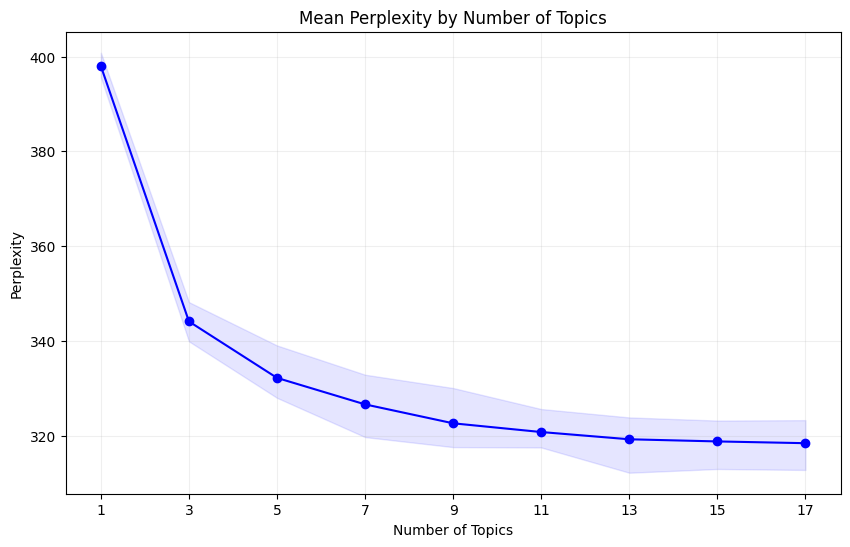

In [3]:
# plot mean test perplexity by num_topics, with min and max as error bars
# the min and max should create a range for the mean
# the plot should be a line plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# plt.errorbar(
#     mean_test_perplexity.index,
#     mean_test_perplexity["mean"],
#     yerr=mean_test_perplexity["max"] - mean_test_perplexity["mean"],
#     fmt="o",
#     capsize=5,
# )

plt.plot(
    mean_test_perplexity.index,
    mean_test_perplexity["mean"],
    color="blue",
    marker="o",
)
plt.fill_between(
    mean_test_perplexity.index,
    mean_test_perplexity["min"],
    mean_test_perplexity["max"],
    color="blue",
    alpha=0.1,
)
plt.xlabel("Number of Topics")
plt.ylabel("Perplexity")
plt.title("Mean Perplexity by Number of Topics")
plt.xticks(mean_test_perplexity.index)
plt.grid(True, alpha=0.2)
plt.show()


In [ ]:
cv_metrics.sort_values(by=["num_topics", "fold"], ascending=[True, True])[
    ["num_topics", "fold", "best_seed", "train_perplexity", "test_perplexity"]
]

,num_topics,fold,best_seed,train_perplexity,test_perplexity
0,1,1,3,373.999227,383.028746
6,1,2,3,374.340222,382.347131
12,1,3,1,374.452404,379.185613
18,1,4,3,373.767875,385.967785
24,1,5,5,374.571398,380.065967
1,3,1,5,317.280582,330.594065
7,3,2,1,314.042725,329.533518
13,3,3,1,312.751578,318.716773
19,3,4,5,312.323564,334.126965
25,3,5,5,312.627773,325.721022


In [ ]:
import json

with open(
    "outputs/comparison_20251016_100909/with_ngrams/full_model_export/topic_word_top_words_16_topics.json",
    "r",
) as fh:
    topic_word_top_words = json.load(fh)

topic_word_top_words

In [ ]:
import pandas as pd

topic_0 = pd.read_csv(
    "outputs/comparison_20251016_100909/with_ngrams/full_model_export/topic_0_document_word_probs.csv"
)
print(topic_0.shape)
topic_0.head()